# Kuraray Y-11 Spectra

Load the digitized Y-11 absorption and emission CSVs, overlay them on the same wavelength axis, smooth them, and save smoothed copies.

This notebook assumes `x` is already wavelength in nm and `y` is relative absorption or emission.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

plt.style.use('seaborn-v0_8-whitegrid')

repo_root = Path.cwd()
data_dir = repo_root / 'analysis' / 'kuraray'
if not data_dir.exists():
    data_dir = Path.cwd()

emission_path = data_dir / 'wls_emission.csv'
absorption_path = data_dir / 'wls_absorption.csv'

emission_path, absorption_path

(PosixPath('/Users/tengiz/cosmic-geant/analysis/kuraray/wls_emission.csv'),
 PosixPath('/Users/tengiz/cosmic-geant/analysis/kuraray/wls_absorption.csv'))

In [2]:
def load_digitized_curve(path: Path, invert_y: bool = False) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(columns={df.columns[0]: 'x', df.columns[1]: 'y'})[['x', 'y']]
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    df = df.groupby('x', as_index=False)['y'].mean().sort_values('x').reset_index(drop=True)
    if invert_y:
        df['y'] = -df['y']
    y = df['y'].to_numpy(dtype=float)
    y = y - y.min()
    if np.ptp(y) > 0:
        y = y / y.max()
    df['intensity_raw'] = y
    return df
def choose_window(n_points: int, requested: int = 21, polyorder: int = 3) -> int:
    window = min(requested, n_points if n_points % 2 == 1 else n_points - 1)
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    window = max(window, minimum)
    if window > n_points:
        window = n_points if n_points % 2 == 1 else n_points - 1
    return max(window, minimum)


def smooth_curve(df: pd.DataFrame, y_col: str = 'intensity_raw', requested_window: int = 21, polyorder: int = 3) -> pd.DataFrame:
    out = df.copy()
    window = choose_window(len(out), requested=requested_window, polyorder=polyorder)
    out['intensity_smooth'] = savgol_filter(out[y_col].to_numpy(dtype=float), window_length=window, polyorder=polyorder)
    out['intensity_smooth'] = np.clip(out['intensity_smooth'], 0.0, None)
    if out['intensity_smooth'].max() > 0:
        out['intensity_smooth'] = out['intensity_smooth'] / out['intensity_smooth'].max()
    out.attrs['window'] = window
    out.attrs['polyorder'] = polyorder
    return out

In [3]:
emission = load_digitized_curve(emission_path, invert_y=False)
absorption = load_digitized_curve(absorption_path, invert_y=True)

display(pd.DataFrame([
    {
        'curve': 'emission',
        'points': len(emission),
        'x_min': emission['x'].min(),
        'x_max': emission['x'].max(),
        'peak_x_raw': emission.loc[emission['intensity_raw'].idxmax(), 'x'],
    },
    {
        'curve': 'absorption',
        'points': len(absorption),
        'x_min': absorption['x'].min(),
        'x_max': absorption['x'].max(),
        'peak_x_raw': absorption.loc[absorption['intensity_raw'].idxmax(), 'x'],
    },
]))

,curve,points,x_min,x_max,peak_x_raw
0,emission,158,176.725557,584.162612,277.825894
1,absorption,143,1.779389,324.159269,171.533085


In [4]:
emission['wavelength_nm'] = emission['x']
absorption['wavelength_nm'] = absorption['x']

display(emission.head())
display(absorption.head())

,x,y,intensity_raw,wavelength_nm
0,176.725557,0.003871,0.004743,176.725557
1,182.512751,0.000740,0.001600,182.512751
2,184.956126,-0.000854,0.000000,184.956126
3,187.318295,0.000272,0.001131,187.318295
4,188.846897,-0.000282,0.000575,188.846897


,x,y,intensity_raw,wavelength_nm
0,1.779389,0.034310,0.034927,1.779389
1,5.369216,0.037230,0.037858,5.369216
2,9.388963,0.041087,0.041729,9.388963
3,13.391991,0.041211,0.041853,13.391991
4,19.496847,0.044418,0.045072,19.496847


In [5]:
emission_smooth = smooth_curve(emission, requested_window=6, polyorder=2)
absorption_smooth = smooth_curve(absorption, requested_window=6, polyorder=2)

print(f"Emission smoothing window: {emission_smooth.attrs['window']}, polyorder: {emission_smooth.attrs['polyorder']}")
print(f"Absorption smoothing window: {absorption_smooth.attrs['window']}, polyorder: {absorption_smooth.attrs['polyorder']}")

Emission smoothing window: 6, polyorder: 2
Absorption smoothing window: 6, polyorder: 2


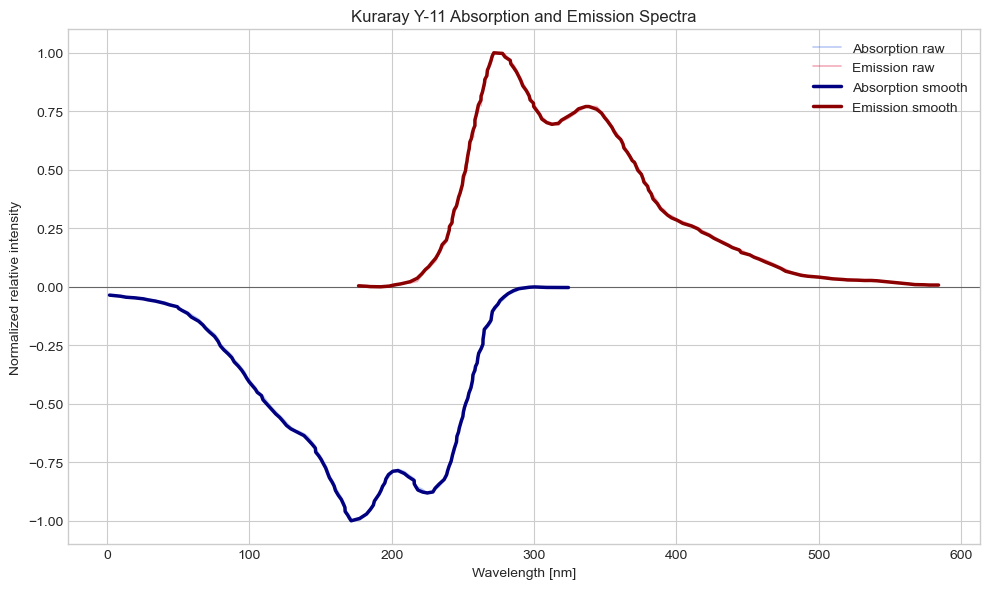

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)

ax.plot(absorption['wavelength_nm'], -absorption['intensity_raw'], color='royalblue', alpha=0.35, linewidth=1.2, label='Absorption raw')
ax.plot(emission['wavelength_nm'], emission['intensity_raw'], color='crimson', alpha=0.35, linewidth=1.2, label='Emission raw')

ax.plot(absorption_smooth['wavelength_nm'], -absorption_smooth['intensity_smooth'], color='navy', linewidth=2.5, label='Absorption smooth')
ax.plot(emission_smooth['wavelength_nm'], emission_smooth['intensity_smooth'], color='darkred', linewidth=2.5, label='Emission smooth')

ax.set_title('Kuraray Y-11 Absorption and Emission Spectra')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Normalized relative intensity')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
emission_out = data_dir / 'wls_emission_smoothed.csv'
absorption_out = data_dir / 'wls_absorption_smoothed.csv'

emission_export = emission_smooth[['wavelength_nm', 'intensity_smooth']].rename(columns={'wavelength_nm': 'x', 'intensity_smooth': 'y'})
absorption_export = absorption_smooth[['wavelength_nm', 'intensity_smooth']].rename(columns={'wavelength_nm': 'x', 'intensity_smooth': 'y'})

emission_export.to_csv(emission_out, index=False)
absorption_export.to_csv(absorption_out, index=False)

print(f'Saved {emission_out}')
print(f'Saved {absorption_out}')

Saved /Users/tengiz/cosmic-geant/analysis/kuraray/wls_emission_smoothed.csv
Saved /Users/tengiz/cosmic-geant/analysis/kuraray/wls_absorption_smoothed.csv
